In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DATA with genotypes

In [4]:
inputs = pd.read_csv("01_prep_inputs.csv", sep=",", header=0, index_col=["id","POP"])
inputs.head()

,,55749196-29-G/A,100283399-40-C/T,100283400-45-A/C,55750931-10-C/T,23141276-42-T/A,100283428-17-C/T,100283429-66-T/A,23147835-9-C/T,100283457-18-C/A,55764801-6-G/A,...,13501202-27-G/A,55836668-31-A/C,23157730-22-T/G,55846148-65-T/C,55860316-28-G/C,55836449-6-T/C,55863991-48-C/T,102640963-40-T/A,55816615-37-A/G,102641000-63-A/G
id,POP,,,,,,,,,,,,,,,,,,,,,
E353-B1_3_6_333_001,333,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,NaN,0.0,0.0,2.0,NaN
E353-B1_3_6_6914_073,6914,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,1.0,2.0,0.0,0.0,0.0,2.0,1.0,NaN,2.0,NaN
E353-B1_3_16_6917_081,6917,0.0,0.0,2.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,2.0,NaN,1.0,0.0,NaN,2.0,NaN,0.0,2.0,2.0
E353-B3_3_7_6802_478,6802,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,1.0,NaN,NaN,NaN,0.0,0.0,2.0,NaN
E353-B3_3_14_6986_371,6986,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN


In [5]:
print(inputs.shape)

(1460, 43001)


# Missing data per site

In [6]:
dt = inputs.iloc[0:10,0:20]
dt

,,55749196-29-G/A,100283399-40-C/T,100283400-45-A/C,55750931-10-C/T,23141276-42-T/A,100283428-17-C/T,100283429-66-T/A,23147835-9-C/T,100283457-18-C/A,55764801-6-G/A,100283500-25-C/T,23148489-53-G/A,100283660-33-C/A,55760984-24-A/G,55749171-62-C/A,100283701-37-A/T,100283776-59-C/A,55774608-18-A/G,55752493-6-A/T,100283847-57-A/C
id,POP,,,,,,,,,,,,,,,,,,,,
E353-B1_3_6_333_001,333,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,2.0
E353-B1_3_6_6914_073,6914,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0
E353-B1_3_16_6917_081,6917,0.0,0.0,2.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2.0
E353-B3_3_7_6802_478,6802,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0
E353-B3_3_14_6986_371,6986,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,2.0,0.0,0.0,1.0,0.0,2.0
E353-B1_3_15_325_017,325,0.0,0.0,2.0,0.0,2.0,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
E353-B1_3_3_332_025,332,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,NaN,2.0
E353-B3_5_11_6804_557,6804,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0,NaN,2.0
E353-B1_3_10_6927_041,6927,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


<Axes: >

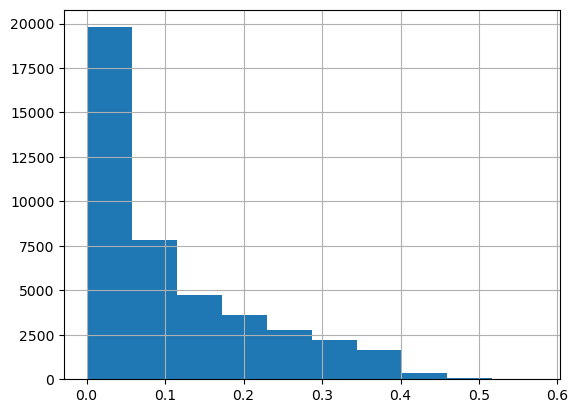

In [7]:
n_sites = inputs.shape[0]
frac_miss = 1 - (inputs.count()/n_sites)
frac_miss.hist()

In [8]:
print(frac_miss.shape)
print(frac_miss[frac_miss<0.01].shape)

(43001,)
(6337,)


In [9]:
#good_snps = frac_miss[frac_miss<0.01].index.values
#good_snps

In [10]:
#df = inputs[good_snps]
#print(df.shape)
#df.head()

In [11]:
#n_sites = df.shape[1]
#n_sites

In [9]:
inputs.reset_index().groupby("POP").agg(n = ('id','count'))

,n
POP,
321,28
325,31
326,23
329,15
332,37
...,...
6983,23
6986,31
6988,25


# One population

In [10]:
inputs.head()

,,55749196-29-G/A,100283399-40-C/T,100283400-45-A/C,55750931-10-C/T,23141276-42-T/A,100283428-17-C/T,100283429-66-T/A,23147835-9-C/T,100283457-18-C/A,55764801-6-G/A,...,13501202-27-G/A,55836668-31-A/C,23157730-22-T/G,55846148-65-T/C,55860316-28-G/C,55836449-6-T/C,55863991-48-C/T,102640963-40-T/A,55816615-37-A/G,102641000-63-A/G
id,POP,,,,,,,,,,,,,,,,,,,,,
E353-B1_3_6_333_001,333,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,NaN,0.0,0.0,2.0,NaN
E353-B1_3_6_6914_073,6914,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,1.0,2.0,0.0,0.0,0.0,2.0,1.0,NaN,2.0,NaN
E353-B1_3_16_6917_081,6917,0.0,0.0,2.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,2.0,NaN,1.0,0.0,NaN,2.0,NaN,0.0,2.0,2.0
E353-B3_3_7_6802_478,6802,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,1.0,NaN,NaN,NaN,0.0,0.0,2.0,NaN
E353-B3_3_14_6986_371,6986,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN


In [11]:
pop = 6969
df = inputs.xs(key=pop, level="POP")
print(df.shape)
df.head()

(7, 43001)


,55749196-29-G/A,100283399-40-C/T,100283400-45-A/C,55750931-10-C/T,23141276-42-T/A,100283428-17-C/T,100283429-66-T/A,23147835-9-C/T,100283457-18-C/A,55764801-6-G/A,...,13501202-27-G/A,55836668-31-A/C,23157730-22-T/G,55846148-65-T/C,55860316-28-G/C,55836449-6-T/C,55863991-48-C/T,102640963-40-T/A,55816615-37-A/G,102641000-63-A/G
id,,,,,,,,,,,,,,,,,,,,,
E60-A_3_1_11_188,NaN,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,NaN,NaN,2.0,0.0,2.0,2.0
E60-A_3_2_11_189,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,NaN
E60-A_4_8_11_458,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,2.0,1.0,NaN,2.0,NaN
E60-A_6_2_11_455,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,2.0,0.0,NaN,0.0,NaN
E60-A_6_3_11_456,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,NaN,...,0.0,2.0,0.0,0.0,NaN,2.0,1.0,NaN,2.0,NaN


# Observed heterozygosity

HO (observed heterozygosity) is the observed proportion of heterozygotes, averaged over loci.  
Ho - proportion of heterozygous genotypes at this locus in the population  

Ho = sum(hi,...,n)/n  
n - number of sites  
hi - the observed heterozygosity at site i (1 if all inds are heterozygotes)  

count proportion of heterozygotes for each site  
Average across sites  

In [19]:
# Number of hets (1) per site
df[df==1].count(axis=1)
# Number of all genotypes per site
df.count(axis=1)
# Prop of hets per site
df[df==12].count(axis=1)/df.count(axis=1)

id
E60-A_3_1_11_188    0.0
E60-A_3_2_11_189    0.0
E60-A_4_8_11_458    0.0
E60-A_6_2_11_455    0.0
E60-A_6_3_11_456    0.0
E60-A_6_4_11_457    0.0
E60-A_5_6_11_634    0.0
dtype: float64

# Expected heterozygosity

Expected heterozygosity (HE, or gene diversity, D)  
For a single locus:   
He = p*q = 1 - (p^2 + q^2) = 1 - sum(pi^2)
for i in k alleles  
pi = frequency of allele i in a locus  

Across m sites:  
He = 1 - (1/m) * (sum across m sites (sum across n alleles (pi^2)))  

1. Loop by each site  
2. Estimate frequency of allele 1 (p) and allele 2 (q) and calculate p^2 & q^2
3. Sum the two S = p^2 + q^2   
4. To average over all snps: sum the sum over all snps = sum(S)
5. Calculate He = 1 - (1/len(snps) * sum(S))  

In [12]:
iteration = 1
subsample = 7

# Random subset of 7 samples
random_state = 7092025 + iteration + int(pop)
df_subset = df.sample(n=subsample, random_state=random_state)
print(df.shape, df_subset.shape)

# Remove missing sites within the pop

# fraction of genotyped samples = n genotyped samples / n rows (n=7)
# fraction of missing samples = 1 - fraction of genotyped samples
frac_miss = 1 - (df_subset.count()/df_subset.shape[0])
good_snps = frac_miss[frac_miss==0].index.values
df_filter = df_subset[good_snps]
print(df.shape, df_subset.shape, df_filter.shape)

# Only polymorphic sites: sum alleles 
df_sum = df_filter.sum()
polymorphic_snps = df_sum[(df_sum>0) & (df_sum<subsample*2)].index.values
df_poly = df_filter[polymorphic_snps]
print(df.shape, df_subset.shape, df_filter.shape, df_poly.shape)

# Number of polymorphic sites
n_poly = len(polymorphic_snps)

# Observed heterozygosity
df_ho = pd.DataFrame(df_poly[df_poly==1].count(axis=1)/df_poly.count(axis=1)).rename(columns={0:"ho"}).reset_index()
Ho = df_ho['ho'].mean()

# Expected heterozygosity
snps = df_poly.columns.values

S = []
for snp in snps:
    dsub_snp = df_poly[snp]
    word = ''.join(dsub_snp.astype(int).astype(str).values.tolist())
    n_ind = len(word)*2 # should be 14
    p_1 = ((word.count('0')*2) + word.count('1'))/n_ind
    p_2 = ((word.count('2')*2) + word.count('1'))/n_ind
    x = p_1**2 + p_2**2
    S.append(x)
He = 1 - (1/len(snps) * sum(S))

R = [pop, iteration, n_poly, Ho, He]
R

(7, 43001) (7, 43001)
(7, 43001) (7, 43001) (7, 24645)
(7, 43001) (7, 43001) (7, 24645) (7, 11031)


[6969, 1, 11031, 0.2550086120931919, 0.30636203352703606]

# Loop over pops

In [13]:
pops = inputs.reset_index()['POP'].drop_duplicates().values
pops

array([ 333, 6914, 6917, 6802, 6986,  325,  332, 6804, 6927, 7000,  321,
        338, 1528, 6968,  369, 1530, 4353,  342, 4277,  336, 1531, 4344,
       6930, 6973,  352, 1534, 4360, 1329, 6805, 3268, 6801, 6909, 6901,
       6988,  345,  355, 6922, 1538, 6938, 6979, 4351,  329, 6999,  326,
       6907, 6965, 6941, 6983, 6967, 6970, 6963, 6808, 2209, 6905, 6977,
       6964, 4420, 6916, 6972, 6980, 6971, 6956, 6969])

In [14]:
R = []
for pop in pops:
    print(pop)

    df = inputs.xs(key=pop, level="POP")
    print(df.shape)

    for iteration in range(5):
        subsample = 7
             
        # Random subset of 7 samples
        random_state = 7092025 + iteration + int(pop)
        df_subset = df.sample(n=subsample, random_state=random_state)
        #print(df.shape, df_subset.shape)
        
        # Remove missing sites
        frac_miss = 1 - (df_subset.count()/df_subset.shape[0])
        good_snps = frac_miss[frac_miss==0].index.values
        df_filter = df_subset[good_snps]
        #print(df.shape, df_subset.shape, df_filter.shape)
        
        # Only polymorphic sites: sum alleles 
        df_sum = df_filter.sum()
        polymorphic_snps = df_sum[(df_sum>0) & (df_sum<subsample*2)].index.values
        df_poly = df_filter[polymorphic_snps]
        print(df.shape, df_subset.shape, df_filter.shape, df_poly.shape)
        
        # Number of polymorphic sites
        n_poly = len(polymorphic_snps)
        
        # Observed heterozygosity
        df_ho = pd.DataFrame(df_poly[df_poly==1].count(axis=1)/df_poly.count(axis=1)).rename(columns={0:"ho"}).reset_index()
        Ho = df_ho['ho'].mean()
        
        # Expected heterozygosity
        snps = df_poly.columns.values
        
        S = []
        for snp in snps:
            dsub_snp = df_poly[snp]
            word = ''.join(dsub_snp.astype(int).astype(str).values.tolist())
            n_ind = len(word)*2 # should be 14
            p_1 = ((word.count('0')*2) + word.count('1'))/n_ind
            p_2 = ((word.count('2')*2) + word.count('1'))/n_ind
            x = p_1**2 + p_2**2
            S.append(x)
        He = 1 - (1/len(snps) * sum(S))
        
        result = [pop, iteration, n_poly, Ho, He]
        R.append(result)
dR = pd.DataFrame(R, columns = ["POP","iter","N_poly", "Ho", "He"])
dR.head()

333
(39, 43001)
(39, 43001) (7, 43001) (7, 24670) (7, 11783)
(39, 43001) (7, 43001) (7, 24785) (7, 11625)
(39, 43001) (7, 43001) (7, 25238) (7, 11743)
(39, 43001) (7, 43001) (7, 24303) (7, 11422)
(39, 43001) (7, 43001) (7, 25252) (7, 12196)
6914
(26, 43001)
(26, 43001) (7, 43001) (7, 23888) (7, 11578)
(26, 43001) (7, 43001) (7, 25211) (7, 12328)
(26, 43001) (7, 43001) (7, 24110) (7, 11626)
(26, 43001) (7, 43001) (7, 23954) (7, 11436)
(26, 43001) (7, 43001) (7, 24402) (7, 11766)
6917
(15, 43001)
(15, 43001) (7, 43001) (7, 24170) (7, 11345)
(15, 43001) (7, 43001) (7, 24162) (7, 11600)
(15, 43001) (7, 43001) (7, 23862) (7, 11239)
(15, 43001) (7, 43001) (7, 24530) (7, 11616)
(15, 43001) (7, 43001) (7, 24114) (7, 11690)
6802
(21, 43001)
(21, 43001) (7, 43001) (7, 24208) (7, 11851)
(21, 43001) (7, 43001) (7, 24089) (7, 11960)
(21, 43001) (7, 43001) (7, 24506) (7, 11976)
(21, 43001) (7, 43001) (7, 24011) (7, 11552)
(21, 43001) (7, 43001) (7, 24092) (7, 11523)
6986
(31, 43001)
(31, 43001) (7, 

,POP,iter,N_poly,Ho,He
0,333,0,11783,0.244141,0.298322
1,333,1,11625,0.249720,0.300277
2,333,2,11743,0.256153,0.296779
3,333,3,11422,0.249368,0.297208
4,333,4,12196,0.251335,0.295859


In [24]:
dR.head()

,POP,iter,N_poly,Ho,He
0,333,0,11783,0.244141,0.298322
1,333,1,11625,0.249720,0.300277
2,333,2,11743,0.256153,0.296779
3,333,3,11422,0.249368,0.297208
4,333,4,12196,0.251335,0.295859


In [25]:
dR.to_csv("02_calculate_heterozygosity.tsv", sep="\t", header=True, index=False)

In [26]:
dR.shape

(315, 5)

<Axes: xlabel='Ho', ylabel='He'>

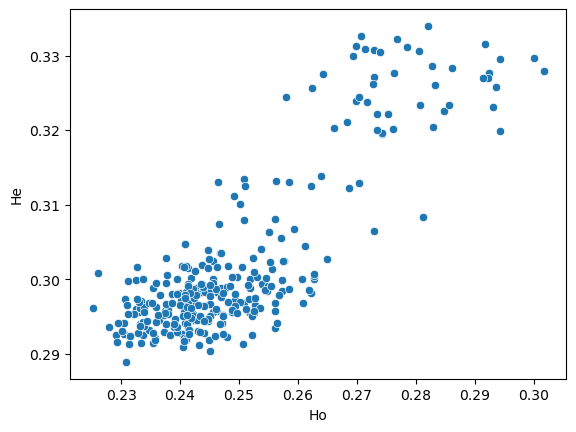

In [27]:
sns.scatterplot(data=dR, x = "Ho", y = "He")

<Axes: xlabel='N_poly', ylabel='Ho'>

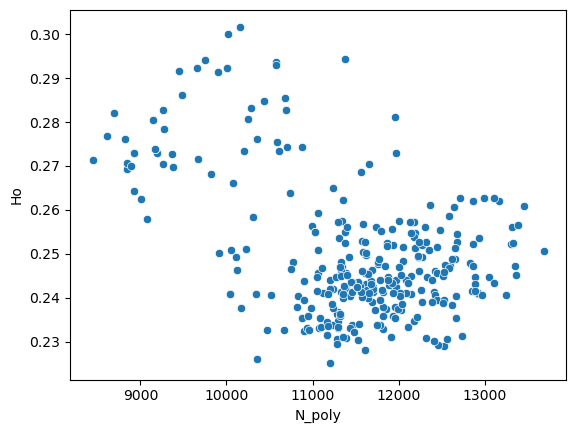

In [23]:
sns.scatterplot(data=dR, x = "N_poly", y = "Ho")